# Análise: Perfil da Turma de Sucesso na UFRN

## Objetivo

Entender quais são as características de uma “turma de sucesso”. Disso, tiraremos as características mais importantes para a clusterização.

Uma turma possui dados que dizem respeito a três pontos:
- Dados do professor: Formação, classe funcional, gênero
- Dados da turma: Quantidade de alunos… (Podemos relacionar com a razão de aprovados da turma (aprovados/qtd total))
- Dados do aluno: Ano de ingresso…


## Importando as bibliotecas necessárias

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
plt.style.use('ggplot')

## Carregando Arquivo CSV

In [32]:
df = pd.read_csv("dataset/avaliacoes_Docentes_Turmas.csv", sep=";")

## Informações gerais

In [33]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126294 entries, 0 to 126293
Data columns (total 28 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  

## Mapa de Correlações

O mapa de correlações foi plotado com o intuito de descobrir as correlações presentes entre os atributos relativos as turmas, aos alunos e aos professores.

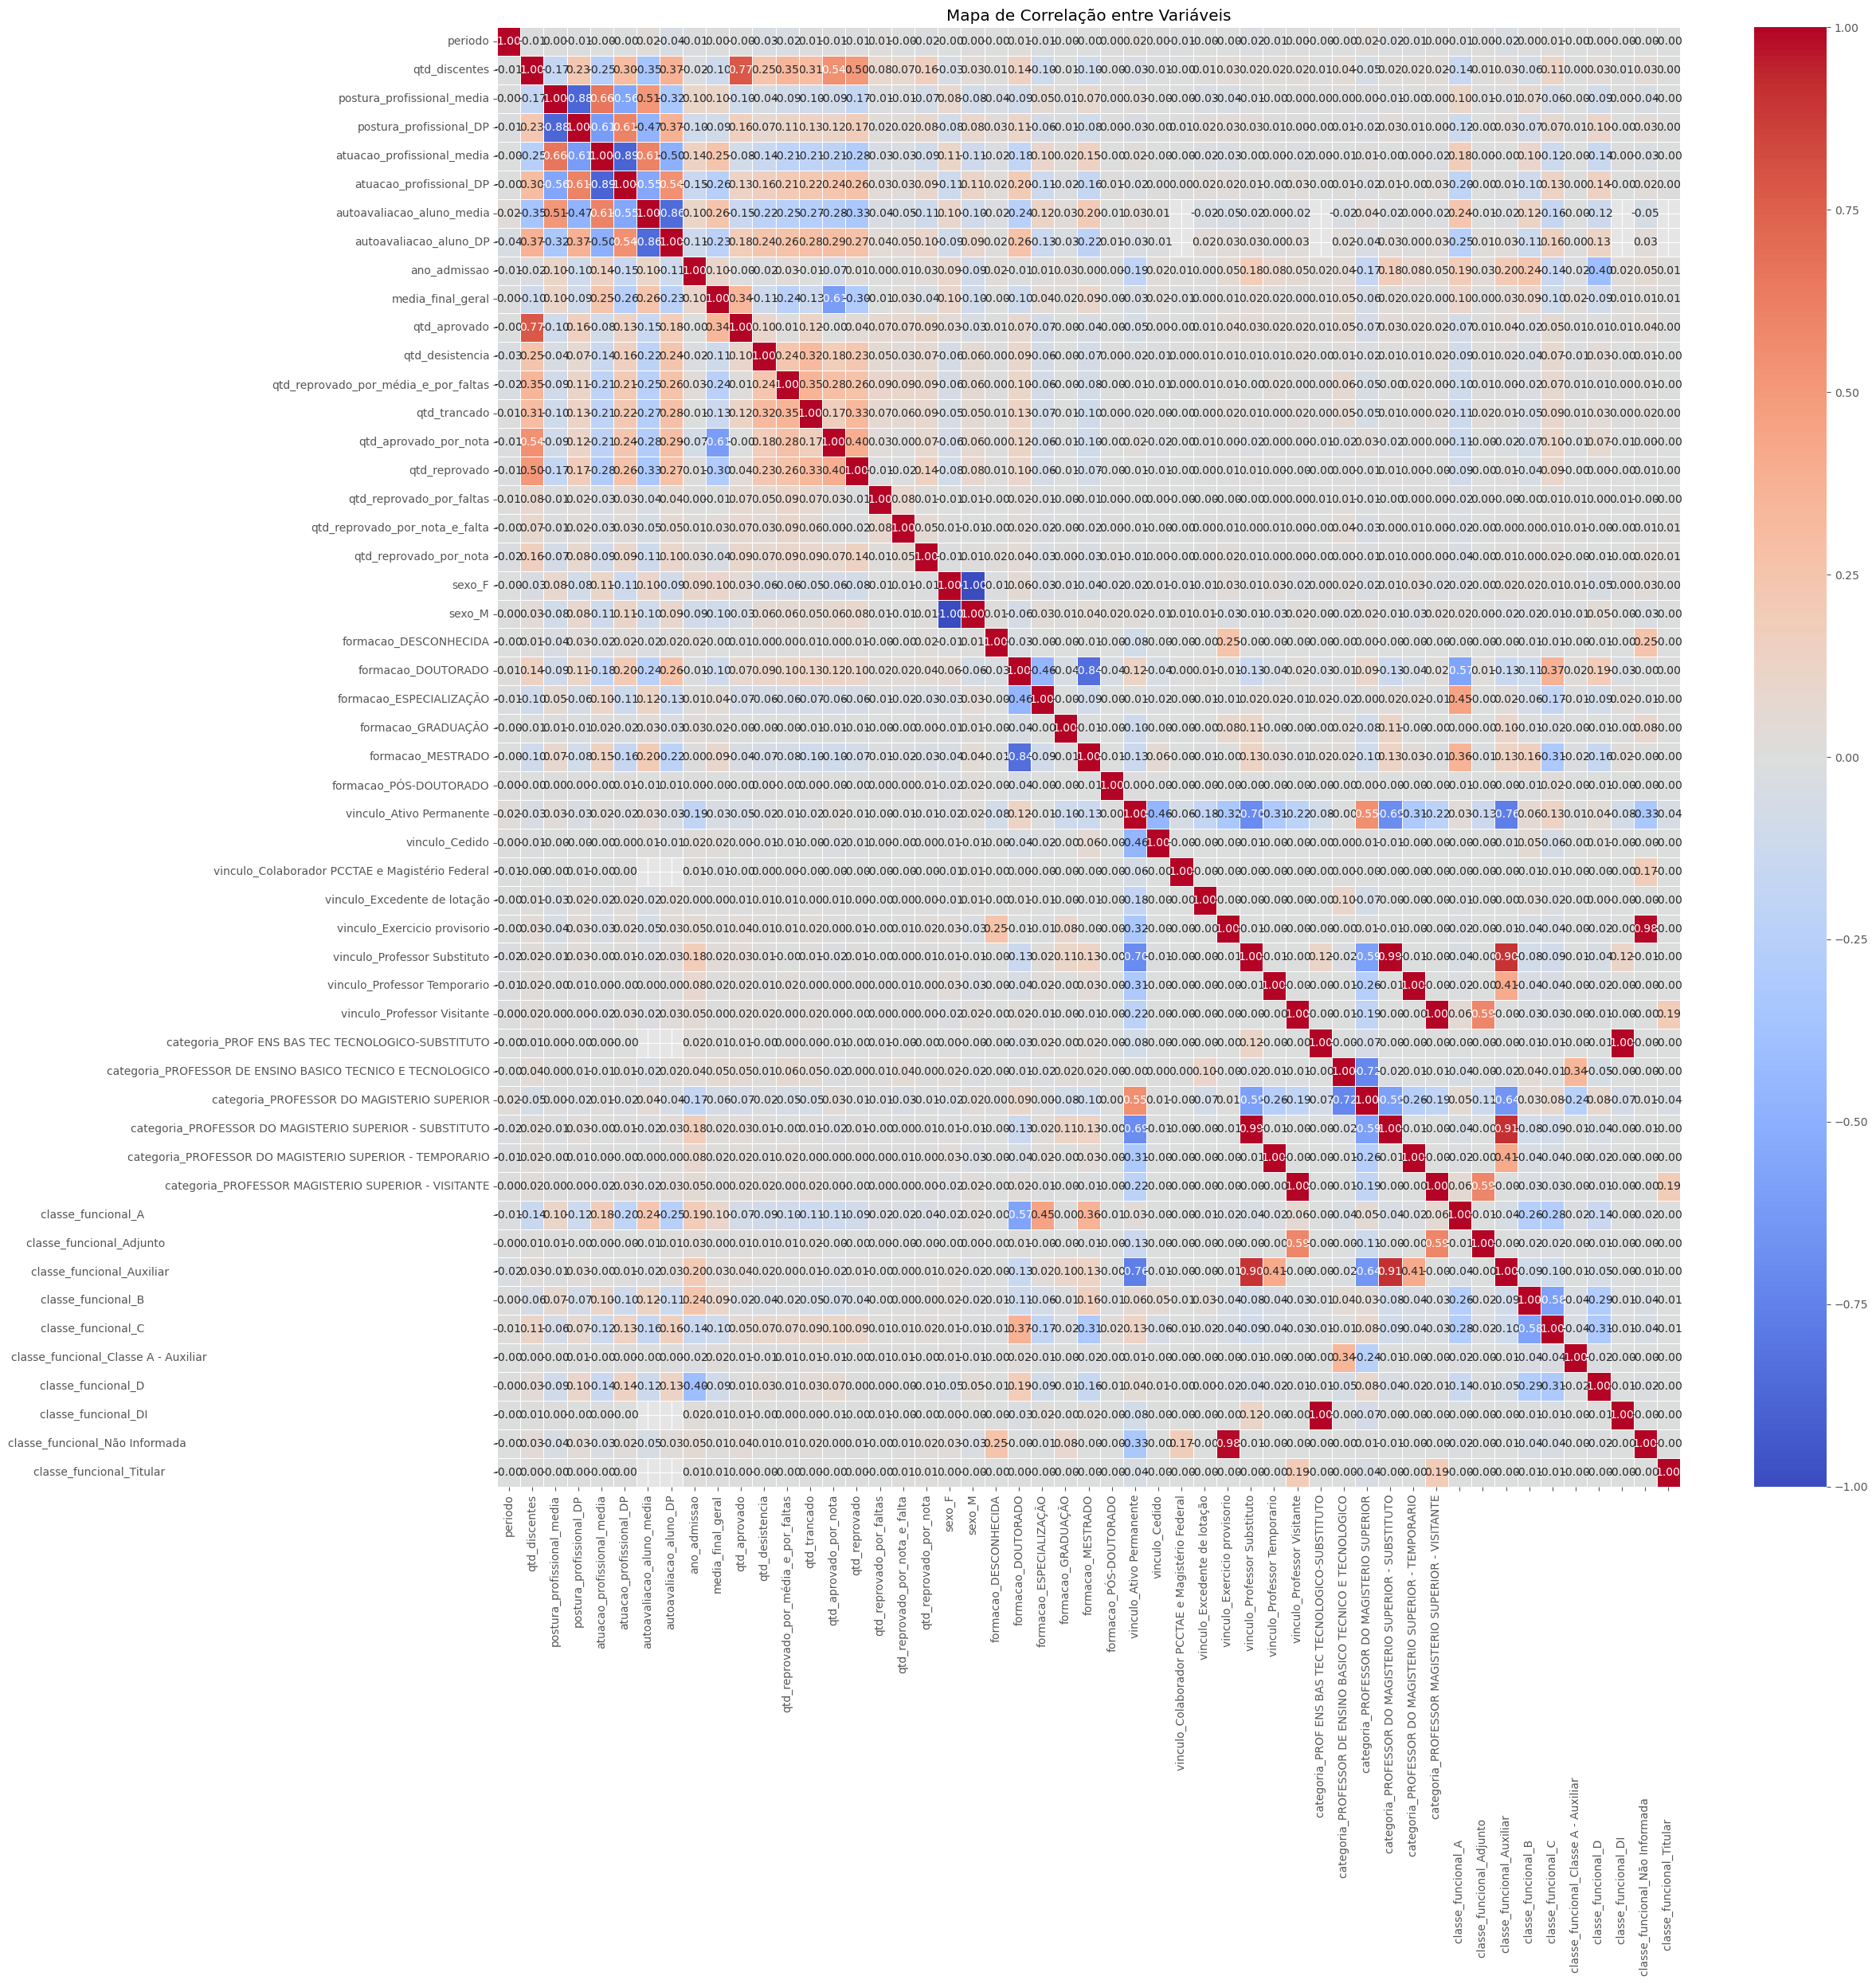

In [34]:
df_encoded = df.drop(columns=['nome', 'id_turma', 'ano', 'lotacao'])

df_encoded = pd.get_dummies(df_encoded)

# Normalizando dados
scaler = MinMaxScaler()
df_normalizado = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

correlacao = df_normalizado.corr()

plt.figure(figsize=(25, 25))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de Correlação entre Variáveis")
plt.tight_layout()
plt.show()

Análise detalhada no Canva: https://www.canva.com/design/DAG0lA39nMU/4HpUcrPz-9FfVultiJwlPw/view?utm_content=DAG0lA39nMU&utm_campaign=designshare&utm_medium=link2&utm_source=uniquelinks&utlId=h262f6db605

A partir da análise do mapa de calor, podemos destacar as seguintes correlações:
- Postura/atuação profissional X Autoavaliações dos alunos
- Postura/atuação profissional X Média da turma e quantidades de aprovados, reprovados e trancados
- Postura/atuação profissional X Formação do discente
- Postura/atuação profissional X Classe funcional
- Postura/atuação profissional X Sexo do discente


CONTINUAR A ESCREVER DEPOIS #SEM_TEMPO !!!!!!!!!



Além disso, podemos perceber que as colunas relacionadas ao tipo de vínculo e de categoria não possuem correlações fortes com nenhuma outra categoria para além da classe funcional. A classe funcional, por sua vez, possui correlações com o desempenho dos professores, e da turma.

Por isso, removeremos os atributos relacionados ao vínculo e à categoria do professor.

## Remoção de atributos inúteis

In [35]:
df_normalizado.columns

Index(['periodo', 'qtd_discentes', 'postura_profissional_media',
       'postura_profissional_DP', 'atuacao_profissional_media',
       'atuacao_profissional_DP', 'autoavaliacao_aluno_media',
       'autoavaliacao_aluno_DP', 'ano_admissao', 'media_final_geral',
       'qtd_aprovado', 'qtd_desistencia',
       'qtd_reprovado_por_média_e_por_faltas', 'qtd_trancado',
       'qtd_aprovado_por_nota', 'qtd_reprovado', 'qtd_reprovado_por_faltas',
       'qtd_reprovado_por_nota_e_falta', 'qtd_reprovado_por_nota', 'sexo_F',
       'sexo_M', 'formacao_DESCONHECIDA', 'formacao_DOUTORADO',
       'formacao_ESPECIALIZAÇÃO', 'formacao_GRADUAÇÃO', 'formacao_MESTRADO',
       'formacao_PÓS-DOUTORADO', 'vinculo_Ativo Permanente', 'vinculo_Cedido',
       'vinculo_Colaborador PCCTAE e Magistério Federal',
       'vinculo_Excedente de lotação', 'vinculo_Exercicio provisorio',
       'vinculo_Professor Substituto', 'vinculo_Professor Temporario',
       'vinculo_Professor Visitante',
       'categoria_PRO

In [36]:
colunas_inuteis = [
    'vinculo', 'categoria', 'ano_admissao'
]

for coluna in colunas_inuteis:
    if coluna in df_normalizado.columns:
        df_normalizado.drop(coluna, axis=1, inplace=True)


A coluna "ano_adimissão" foi removida porque os valores estão incoerentes.

Pelo mapa de correlação, achei que seriam várias colunas, mas esqueci que tínhamos feito one-hot encoding.

Isso foi bem anti-climático...

## Novo CSV resultante dessa análise

In [37]:
df_normalizado.to_csv('completo_normalizado_clustering.csv', index = False)